# Credit Card Default — Exploratory Data Analysis

## Overview
This notebook explores the UCI Credit Card Default dataset, which contains
30,000 rows of Taiwan credit card customers. The goal is to understand the
data before modeling.

**Target variable:** `default.payment.next.month` — 1 means the customer
defaulted, 0 means they didn't.

## Key questions we want to answer
- How imbalanced is the target variable?
- Which features correlate most strongly with default?
- Are there any data quality issues to address before modeling?

# Key

### SEX: 
Gender (1=male, 2=female)

### EDUCATION: 
(1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

### MARRIAGE: 
Marital status (1=married, 2=single, 3=others)

### Remaining Data
LIMIT_BAL — credit limit

PAY_0 through PAY_6 — payment status for September through April (negative = paid early, 0 = on time, 1+ = months late)

BILL_AMT1 through BILL_AMT6 — bill statement amounts

PAY_AMT1 through PAY_AMT6 — actual payment amounts made

default.payment.next.month — your target (1 = defaulted)

In [2]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/credit_card_data.csv')

#outline
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


The dataset has 30,000 rows and 25 columns. Each row is one credit card customer. The target variable is default.payment.next.month — 1 means they defaulted, 0 means they didn't.

In [4]:
df.info()        # column types and null counts
df.describe()    # min, max, mean, std for every numeric column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [5]:
default_counts = df['default.payment.next.month'].value_counts()
print(default_counts)
print(f"\nDefault rate: {default_counts[1] / len(df) * 100:.1f}%")

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.1%


## What this means:
The dataset is imbalanced because only 22% of customers defaulted. This means we cannot use accuracy as our primary metric, since a model that predicts 'no default' for everyone would be 78% accurate but completely useless.

/var/folders/qt/nxn4lmv921s4jn5kxzs_j3d00000gn/T/ipykernel_71503/1442062219.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('age_group')['default.payment.next.month'].mean()


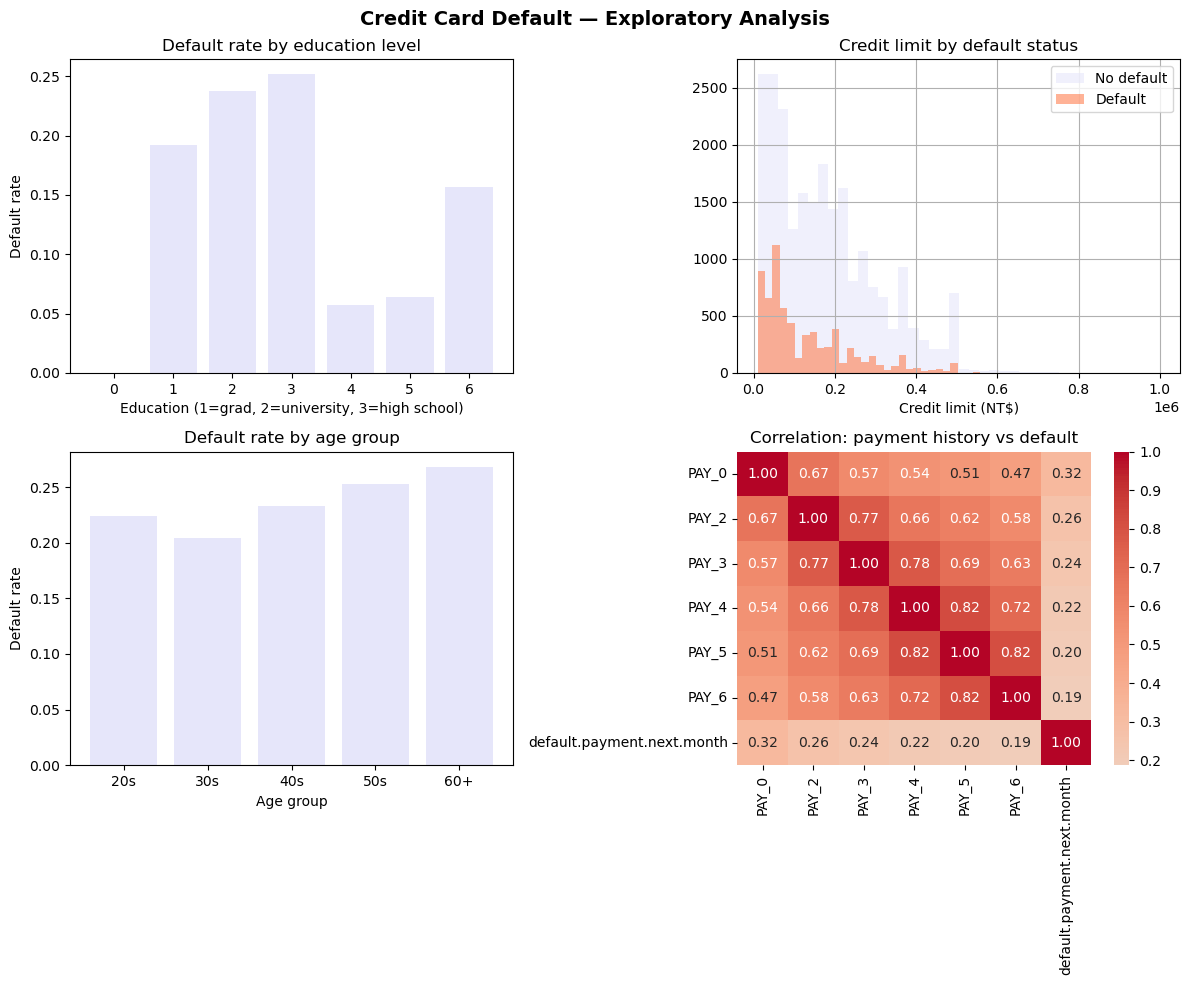

In [10]:
#Charts

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Credit Card Default — Exploratory Analysis', fontsize=14, fontweight='bold')

# Chart 1: Default rate by education level
edu_default = df.groupby('EDUCATION')['default.payment.next.month'].mean()
axes[0,0].bar(edu_default.index, edu_default.values, color='lavender')
axes[0,0].set_title('Default rate by education level')
axes[0,0].set_xlabel('Education (1=grad, 2=university, 3=high school)')
axes[0,0].set_ylabel('Default rate')

# Chart 2: Credit limit distribution by default status
df[df['default.payment.next.month']==0]['LIMIT_BAL'].hist(
    ax=axes[0,1], alpha=0.6, label='No default', bins=40, color='lavender')
df[df['default.payment.next.month']==1]['LIMIT_BAL'].hist(
    ax=axes[0,1], alpha=0.6, label='Default', bins=40, color='coral')
axes[0,1].set_title('Credit limit by default status')
axes[0,1].set_xlabel('Credit limit (NT$)')
axes[0,1].legend()

# Chart 3: Default rate by age group
df['age_group'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80],
                          labels=['20s','30s','40s','50s','60+'])
age_default = df.groupby('age_group')['default.payment.next.month'].mean()
axes[1,0].bar(age_default.index, age_default.values, color='lavender')
axes[1,0].set_title('Default rate by age group')
axes[1,0].set_xlabel('Age group')
axes[1,0].set_ylabel('Default rate')

# Chart 4: Payment status heatmap (are late payers staying late?)
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
pay_corr = df[pay_cols + ['default.payment.next.month']].corr()
sns.heatmap(pay_corr, ax=axes[1,1], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
axes[1,1].set_title('Correlation: payment history vs default')

plt.tight_layout()
plt.savefig('../images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

- Customers with higher credit limits default at lower rates — likely a proxy for creditworthiness at approval time
- Payment delinquency in September (PAY_0) is the single strongest correlate with default
- Default rates among high schoolers are the highest.

In [14]:
#renamed colums
df = df.rename(columns={
    'default.payment.next.month': 'default',
    'PAY_0': 'pay_sep', 'PAY_2': 'pay_aug', 'PAY_3': 'pay_jul',
    'PAY_4': 'pay_jun', 'PAY_5': 'pay_may', 'PAY_6': 'pay_apr',
    'BILL_AMT1': 'bill_sep', 'BILL_AMT2': 'bill_aug', 'BILL_AMT3': 'bill_jul',
    'BILL_AMT4': 'bill_jun', 'BILL_AMT5': 'bill_may', 'BILL_AMT6': 'bill_apr',
    'PAY_AMT1': 'paid_sep', 'PAY_AMT2': 'paid_aug', 'PAY_AMT3': 'paid_jul',
    'PAY_AMT4': 'paid_jun', 'PAY_AMT5': 'paid_may', 'PAY_AMT6': 'paid_apr',
    'LIMIT_BAL': 'credit_limit', 'AGE': 'age',
    'SEX': 'sex', 'EDUCATION': 'education', 'MARRIAGE': 'marriage'
})

#undocumented vals

df['education'] = df['education'].replace({0: 4, 5: 4, 6: 4})
df['marriage'] = df['marriage'].replace({0: 3})

# No nulls remain
print(df.isnull().sum())

ID              0
credit_limit    0
sex             0
education       0
marriage        0
age             0
pay_sep         0
pay_aug         0
pay_jul         0
pay_jun         0
pay_may         0
pay_apr         0
bill_sep        0
bill_aug        0
bill_jul        0
bill_jun        0
bill_may        0
bill_apr        0
paid_sep        0
paid_aug        0
paid_jul        0
paid_jun        0
paid_may        0
paid_apr        0
default         0
age_group       0
dtype: int64


### The EDUCATION and MARRIAGE columns contain undocumented category values (0, 5, 6). Following standard practice, these are consolidated into the existing 'other' category rather than dropped, preserving all 30,000 rows.

In [15]:
bill_cols = ['bill_sep','bill_aug','bill_jul','bill_jun','bill_may','bill_apr']
paid_cols = ['paid_sep','paid_aug','paid_jul','paid_jun','paid_may','paid_apr']
pay_cols  = ['pay_sep','pay_aug','pay_jul','pay_jun','pay_may','pay_apr']

# Average payment ratio

ratios = []
for bill, paid in zip(bill_cols, paid_cols):
    ratio = df[paid] / df[bill].replace(0, np.nan)  
    ratios.append(ratio)
df['avg_payment_ratio'] = pd.concat(ratios, axis=1).mean(axis=1).fillna(0)

# Months delinquent
df['months_delinquent'] = (df[pay_cols] > 0).sum(axis=1)

# Bill growth trend
df['bill_growth'] = df['bill_sep'] - df['bill_apr']

**avg_payment_ratio** captures whether a customer pays in full or only minimum payments — a strong behavioral signal of financial stress
**months_delinquent** distills six months of payment status into one interpretable count

**bill_growth** flags customers whose debt is accelerating, which often precedes default

In [16]:
# training & testing
from sklearn.model_selection import train_test_split

features_to_drop = ['default', 'ID', 'age_group']
X = df.drop(columns=[c for c in features_to_drop if c in df.columns])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")
print(f"Default rate in train: {y_train.mean():.1%}")
print(f"Default rate in test:  {y_test.mean():.1%}")

Training rows: 24000
Test rows:     6000
Default rate in train: 22.1%
Default rate in test:  22.1%


In [17]:
df.to_csv('../data/credit_card_clean.csv', index=False)